In [1]:
#Linear regression

In [2]:
# Scenario: Predicting House Prices Based on Area

# A real estate company wants to predict the price of a house based on its area (in square feet). They collected data from recently sold houses.

# They believe there is a linear relationship:


# Price=m×Area+b

# Your task is to:

# Load the dataset

# Visualize the data

# Train a Linear Regression model

# Predict house prices

# Evaluate the model

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score


data={
    "Area_Sqft":[600,700,1500,300,4500,5000,3500,700,1900,3000],
    "Price":[60,40,30,70,50,50,90,20,80,40]
}

In [27]:
data

{'Area_Sqft': [600, 700, 1500, 300, 4500, 5000, 3500, 700, 1900, 3000],
 'Price': [60, 40, 30, 70, 50, 50, 90, 20, 80, 40]}

In [28]:
df=pd.DataFrame(data)
print("Dataset: ",df)

Dataset:     Area_Sqft  Price
0        600     60
1        700     40
2       1500     30
3        300     70
4       4500     50
5       5000     50
6       3500     90
7        700     20
8       1900     80
9       3000     40


In [29]:
X=df[['Area_Sqft']]
y=df['Price']

#train and test data
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

#Train Linear Model
model=LinearRegression()
model.fit(xtrain,ytrain)

LinearRegression()

In [30]:
print('\nSlope (m): ',model.coef_[0])
print('\nIntercept(b): ',model.intercept_)


Slope (m):  0.00195630740490893

Intercept(b):  46.57931607077993


In [31]:
ypred=model.predict(xtest)
print('\nActual vs Predicted: ')
for actual,pred in zip(ytest,ypred):
    print(f"Actual: {actual:.2f}, Predicted: {pred:.2f}")


Actual vs Predicted: 
Actual: 80.00, Predicted: 50.30
Actual: 40.00, Predicted: 47.95


In [32]:
mae=mean_absolute_error(ytest,ypred)
r2=r2_score(ytest,ypred)

print('\nMean Absolute Error: ',mae)
print('\nR2 score: ',r2)


Mean Absolute Error:  18.826215557054642

R2 score:  -0.18186514239795826


In [33]:
newarea=np.array([[1800]])
predictedprice=model.predict(newarea)
print('\n Predicted Price',predictedprice)


 Predicted Price [50.1006694]


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


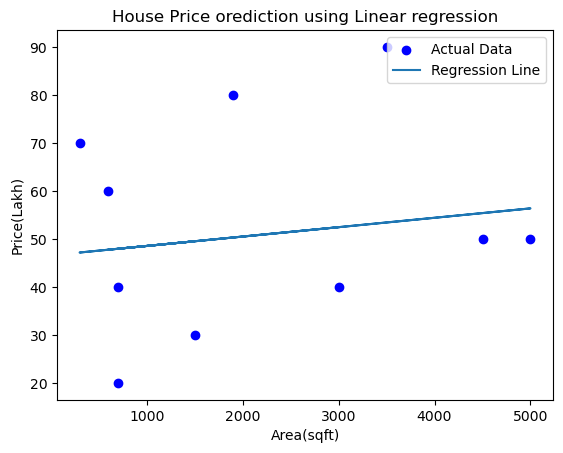

In [34]:
plt.scatter(X,y,color='blue',label='Actual Data')
plt.plot(X,model.predict(X),label="Regression Line")
plt.xlabel("Area(sqft)")
plt.ylabel("Price(Lakh)")
plt.title('House Price orediction using Linear regression')
plt.legend()
plt.show()

In [35]:
#Multilinear Regression Scenario

# Scenario: Predicting House Price Based on Multiple Factors

# A real estate company wants to predict the price of a house based on several important features:

# Area (square feet)

# Number of bedrooms

# Age of the house (years)

# Distance from city center (km)

# Since multiple factors influence price, we use Multiple Linear Regression.

# Price=b0+b1(Area)+b2(Bedrooms)+b3(Age)+b4(Distance)

In [37]:
data = {
    "Area_sqft": [800,1000,1200,1500,1800,2000,2200,2500,900,1600,1400,2100],
    "Bedrooms": [2,2,3,3,4,4,4,5,2,3,3,4],
    "Age_years": [15,10,8,5,4,3,2,1,12,6,7,3],
    "Distance_km": [12,10,8,6,5,4,3,2,11,7,9,4],
    "Price_lakhs": [40,50,62,75,90,105,120,140,45,80,70,110]
}
df=pd.DataFrame(data)
print("Dataset: ")
print(df)
    

Dataset: 
    Area_sqft  Bedrooms  Age_years  Distance_km  Price_lakhs
0         800         2         15           12           40
1        1000         2         10           10           50
2        1200         3          8            8           62
3        1500         3          5            6           75
4        1800         4          4            5           90
5        2000         4          3            4          105
6        2200         4          2            3          120
7        2500         5          1            2          140
8         900         2         12           11           45
9        1600         3          6            7           80
10       1400         3          7            9           70
11       2100         4          3            4          110


In [39]:
X=df[['Area_sqft','Bedrooms','Age_years','Distance_km']]
y=df['Price_lakhs']

xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(xtrain,ytrain)


LinearRegression()

In [40]:
print('\nModel Coefficient: ',model.coef_[0])
print('\nModel intercept: ',model.intercept_)


Model Coefficient:  0.0594807520143241

Model intercept:  14.178155774395648


In [41]:
ypred=model.predict(xtest)

for actual,pred in zip(ytest,ypred):
    print(f'\nActual: {actual:.2f},\nPredicted: {pred:.2f}')


Actual: 70.00,
Predicted: 54.90

Actual: 80.00,
Predicted: 78.73

Actual: 40.00,
Predicted: 54.54


In [43]:
print('\nMean Absolute Error: ',mean_absolute_error(ytest,ypred))


Mean Absolute Error:  10.305282005371533


In [47]:
new_house_df=pd.DataFrame({'Area_sqft':[1700],'Bedrooms':[3],'Age_years':[5],'Distance_km':[6]})
predicted_price=model.predict(new_house_df)

In [48]:
print(new_house_df)

   Area_sqft  Bedrooms  Age_years  Distance_km
0       1700         3          5            6


In [46]:
print(predicted_price)

[86.75828111]


In [49]:
new_house_df=pd.DataFrame({'Area_sqft':[900],'Bedrooms':[2],'Age_years':[11],'Distance_km':[6]})
predicted_price=model.predict(new_house_df)

In [50]:
print(predicted_price)

[88.52193375]


In [51]:
# Scenario: Predicting Employee Salary Based on Multiple Factors

# A company wants to predict employee salary based on several important factors:

# Years of Experience

# Education Level (1 = Bachelor, 2 = Master, 3 = PhD)

# Number of Skills Known

# Performance Rating (1 to 5)

# Since salary depends on multiple variables, the company uses Multiple Linear Regression.

# Salary=b0​+b1​(Experience)+b2​(EducationLevel)+b3​(Skills)+b4​(Performance)

In [53]:
df=pd.DataFrame(pd.read_csv("multil_salary_pred - Sheet1.csv"))
df

,Experience_years,Education_Level,Skills_Count,Performance_Rating,Salary_lpa
0,1,1,3,3,4.0
1,2,1,4,3,5.0
2,3,2,5,4,7.0
3,4,2,6,4,8.0
4,5,2,7,5,10.0
5,6,3,8,5,12.0
6,7,3,9,4,13.0
7,8,3,10,5,15.0
8,2,1,3,2,4.5
9,4,2,5,3,7.5


In [55]:
X=df[['Experience_years','Education_Level','Skills_Count','Performance_Rating']]
y=df['Salary_lpa']

xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.3,random_state=42)

In [56]:
model=LinearRegression()
model.fit(xtrain,ytrain)


LinearRegression()

In [58]:
ypred=model.predict(xtest)

for actual,pred in zip(ytest,ypred):
    print(f'\nActual: {actual:.2f},\nPredicted: {pred:.2f}')


Actual: 11.00,
Predicted: 10.99

Actual: 7.50,
Predicted: 7.78

Actual: 4.00,
Predicted: 3.35

Actual: 4.50,
Predicted: 4.25


In [59]:
new_salary_df=pd.DataFrame({'Experience_years':[5],'Education_Level':[3],'Skills_Count':[11],'Performance_Rating':[4]})
predicted_sal=model.predict(new_salary_df)

In [62]:
print(new_salary_df)

   Experience_years  Education_Level  Skills_Count  Performance_Rating
0                 5                3            11                   4


In [63]:
print(predicted_sal)

[11.41764706]
